In [1]:
import scipy
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn.objects as so

from sklearn import linear_model    # Herramientas de modelos lineales
from sklearn.metrics import mean_squared_error, r2_score    # Medidas de desempeño
from sklearn.preprocessing import PolynomialFeatures    # Herramientas de polinomios

from formulaic import Formula

# Modelo Lineal Multivariado

### Ejercicio 1. Vaiables de oferta

Utilizamos el dataset *macro_full_columns.csv*

(a) Generar un Dataframe que contenga solo las variables que terminan con .oferta ¿Había datos faltantes en estas columnas?

In [6]:
data = pd.read_csv('datasets/macro_full_columns.csv')

data.isna().sum()

Unnamed: 0                              0
Anio                                    0
FBKF.Construcciones.Priv_Publ           0
FBKF.Equi_Dur_Prod.Mat_Transp.Nac       0
FBKF.Equi_Dur_Prod.Mat_Transp.Import    0
                                       ..
Vol_Cons_Hogares_per_Cap__vari_Porc     1
Vol_FBKF_perCap__variPorc               1
Vol_PIB_encaden_Fisher_2004             0
IPI_volumen                             0
IPI__variPorc                           1
Length: 85, dtype: int64

In [11]:
dataOfertas = data[[col for col in data.columns if (col.endswith(".oferta"))]]

dataOfertas.isna().sum()

Agricultura_caza_silvicultura_y_pesca.oferta     0
Explotacion_de_minas_y_canteras.oferta           0
Industria_manufacturera.oferta                   0
Electricidad_gas_y_agua.oferta                   0
Construccion.oferta                              0
Comercio_hoteles_y_restaurantes.oferta           0
Transp_Almac_y_Comunics.oferta                   0
Inter_Fin_Seg_Activ_Inmo_Serv_Empr_etc.oferta    0
Servs_Socs_Comunales_Y_Personales.oferta         0
Impuesto_Prod_Netos_De_Subsid.oferta             0
PBI_a_precios_de_mercado.oferta                  0
dtype: int64

No había NaN :D

(b) Queremos explicar la variable PBI_a_precios_de_mercado.oferta utilizando el resto de las variables de oferta. Crear un DataFrame X que contenga todas las variables de oferta excepto la de PBI y una Series y que contenga sólo la variable de PBI.

In [36]:
y,X = (
    Formula("PBI_a_precios_de_mercado.oferta ~ Agricultura_caza_silvicultura_y_pesca.oferta + Explotacion_de_minas_y_canteras.oferta+ Industria_manufacturera.oferta + Electricidad_gas_y_agua.oferta + Construccion.oferta + Comercio_hoteles_y_restaurantes.oferta + Transp_Almac_y_Comunics.oferta + Inter_Fin_Seg_Activ_Inmo_Serv_Empr_etc.oferta + Servs_Socs_Comunales_Y_Personales.oferta + Impuesto_Prod_Netos_De_Subsid.oferta - 1 ")
    .get_model_matrix(dataOfertas)
)
y = y.iloc[:, 0]
y, X

(0     1.420980e+11
 1     1.474360e+11
 2     1.404910e+11
 3     1.473240e+11
 4     1.533160e+11
           ...     
 61    7.118760e+11
 62    7.064210e+11
 63    7.220400e+11
 64    7.056120e+11
 65    7.225620e+11
 Name: PBI_a_precios_de_mercado.oferta, Length: 66, dtype: float64,
     Agricultura_caza_silvicultura_y_pesca.oferta  \
 0                                    13696637358   
 1                                    14629457210   
 2                                    12545616104   
 3                                    16402296333   
 4                                    16308747029   
 ..                                           ...   
 61                                   51232247600   
 62                                   44579958519   
 63                                   49721752068   
 64                                   51321551605   
 65                                   54675970819   
 
     Explotacion_de_minas_y_canteras.oferta  Industria_manufacturera.ofert

(c) Ajustar aun modelo lineal y generar el vector de predicciones.

In [37]:
modelo1 = linear_model.LinearRegression(fit_intercept=False)
modelo1.fit(X,y)

y_pred = modelo1.predict(X)
modelo1.coef_

array([1.02109063, 0.56903698, 1.11937854, 1.93258341, 1.62701905,
       0.5449714 , 1.1912698 , 0.97673614, 1.18960347, 0.92484204])

(d) Graficar, en un mismo gráfico, la variable respuesta original y la predicha en función del año. Sugerencia: Prestar atención a los índices de cada variable.

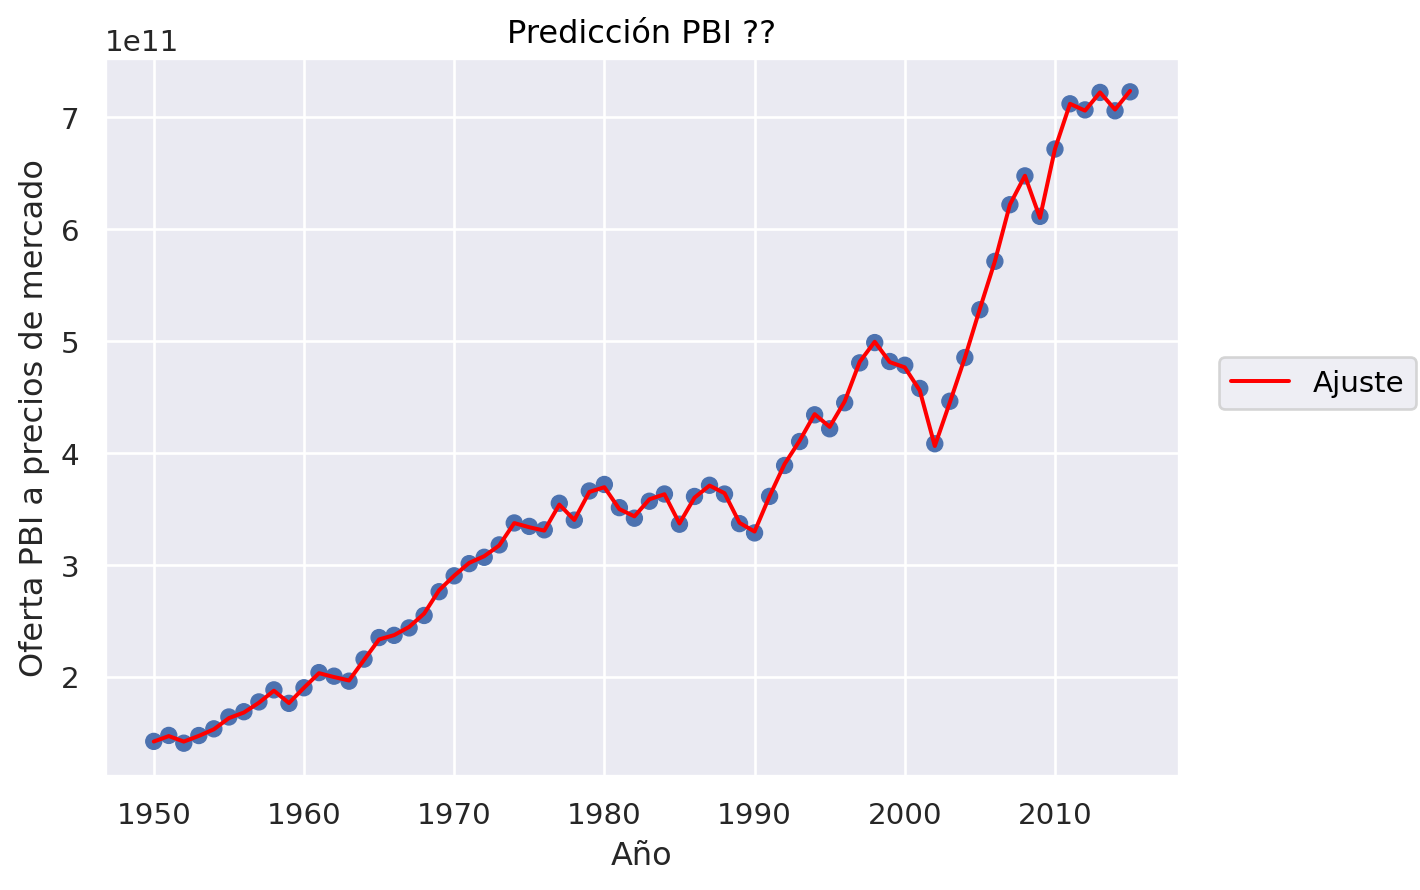

In [38]:
(
    so.Plot(data, x="Anio", y="PBI_a_precios_de_mercado.oferta")
    .add(so.Dot())
    .add(so.Line(color="red"), x="Anio", y=y_pred, label="Ajuste")
).label(y = "Oferta PBI a precios de mercado",x ="Año",title ="Predicción PBI ??")

Por qué salió TAN bien? sólo sabe Dios. Mi apuesta es que ésto está overfitteado y usamos demasiadas variables.

### Ejercicio 17.
Hallar un escalamiento lineal _f(x)_ que transforme los valores del intervalo [2,5] a valores en el intervalo [0,1]

eeemmmm y = 3 * x + 2?

### Ejercicio 18.
Para éste ejercicio utilizar los datos de _CollegeBasketballPlayers2009-2001.csv_

(a) Ajustar un modelo de regresión para predecir los puntos promedio (pts) en función de las demás variables. Comparar los coeficientes del modelo obtenido sin escalar variables con los coeficientes que se obtienen primero si se escalan las variables utilizando el escalamiento MinMax

In [40]:
# importamos el dataset 

collegeBasketball = pd.read_csv('datasets/CollegeBasketballPlayers2009-2021.csv')
collegeBasketball.info()

<class 'pandas.DataFrame'>
RangeIndex: 61061 entries, 0 to 61060
Data columns (total 66 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   player_name                      61061 non-null  str    
 1   team                             61061 non-null  str    
 2   conf                             61061 non-null  str    
 3   GP                               61061 non-null  int64  
 4   Min_per                          61061 non-null  float64
 5   Ortg                             61061 non-null  float64
 6   usg                              61061 non-null  float64
 7   eFG                              61061 non-null  float64
 8   TS_per                           61061 non-null  float64
 9   ORB_per                          61061 non-null  float64
 10  DRB_per                          61061 non-null  float64
 11  AST_per                          61061 non-null  float64
 12  TO_per                       

/tmp/ipykernel_10249/2545238534.py:3: DtypeWarning: Columns (0: num) have mixed types. Specify dtype option on import or set low_memory=False.
  collegeBasketball = pd.read_csv('datasets/CollegeBasketballPlayers2009-2021.csv')


In [41]:
collegeBasketball.isna().sum()

player_name       0
team              0
conf              0
GP                0
Min_per           0
               ... 
stl              38
blk              38
pts              38
Unnamed: 64    4684
Unnamed: 65      45
Length: 66, dtype: int64

Me voy a tomar el atrevimiento de eliminar la columna Unnamed: 64 porque tiene muchos nan. De hecho, en una clase teórica 14 del primer cuatri de 2024 hacen lo mismo. Dropeando in cluso todas las columnas que no son numéricas.

In [45]:
basketNumeric = collegeBasketball.select_dtypes(include='number')
basketNumeric.isna().sum()

GP                                     0
Min_per                                0
Ortg                                   0
usg                                    0
eFG                                    0
TS_per                                 0
ORB_per                                0
DRB_per                                0
AST_per                                0
TO_per                                 0
FTM                                    0
FTA                                    0
FT_per                                 0
twoPM                                  0
twoPA                                  0
twoP_per                               0
TPM                                    0
TPA                                    0
TP_per                                 0
blk_per                                0
stl_per                                0
ftr                                    0
porpag                                 0
adjoe                                  0
pfr             

In [46]:
nan_cols = basketNumeric.isna().sum() > 100
keep = nan_cols.index[~(nan_cols)]
basketNumeric = basketNumeric[keep]

In [50]:
basketNumeric

,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,AST_per,TO_per,...,ogbpm,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,Unnamed: 65
0,26,29.5,97.3,16.6,42.5,44.43,1.6,4.6,15.8,16.3,...,-2.781990,-1.941150,0.1923,0.6154,0.8077,1.1923,0.3462,0.0385,3.8846,6.22026
1,34,60.9,108.3,14.9,52.4,54.48,3.8,6.3,13.6,19.8,...,-0.052263,-0.247934,0.6765,1.2647,1.9412,1.8235,0.4118,0.2353,5.9412,3.94375
2,27,72.0,96.2,21.8,45.7,47.98,2.1,8.0,14.7,15.9,...,1.548230,-0.883163,0.6296,2.3333,2.9630,1.9630,0.4815,0.0000,12.1852,10.92680
3,30,44.5,97.7,16.0,53.6,53.69,4.1,9.4,13.7,23.8,...,-0.342775,-0.393459,0.7000,1.4333,2.1333,1.1000,0.5667,0.1333,4.9333,6.77427
4,33,56.2,96.5,22.0,52.8,54.31,8.3,18.6,8.2,22.7,...,-1.684860,-0.668318,1.4242,3.3030,4.7273,0.8485,0.4545,0.3333,7.5758,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61056,2,0.3,60.5,19.3,0.0,0.00,0.0,0.0,51.1,0.0,...,2.143290,16.018200,0.0000,0.0000,0.0000,0.5000,0.5000,0.0000,0.0000,0.00000
61057,4,1.3,28.3,7.1,0.0,0.00,7.0,0.0,0.0,50.3,...,-7.242230,-4.993820,0.2500,0.0000,0.2500,0.0000,0.0000,0.0000,0.0000,0.00000
61058,1,0.1,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,...,-3.524820,-1.126810,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.00000
61059,1,0.1,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,...,-1.876040,-2.380750,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.00000


In [48]:
basketNumeric.isna().sum()

GP              0
Min_per         0
Ortg            0
usg             0
eFG             0
TS_per          0
ORB_per         0
DRB_per         0
AST_per         0
TO_per          0
FTM             0
FTA             0
FT_per          0
twoPM           0
twoPA           0
twoP_per        0
TPM             0
TPA             0
TP_per          0
blk_per         0
stl_per         0
ftr             0
porpag          0
adjoe           0
pfr             0
year            0
pid             0
drtg           45
adrtg          45
dporpag        45
stops          45
bpm            45
obpm           45
dbpm           45
gbpm           45
mp             38
ogbpm          45
dgbpm          45
oreb           38
dreb           38
treb           38
ast            38
stl            38
blk            38
pts            38
Unnamed: 65    45
dtype: int64

In [49]:
basketNumericClean = basketNumeric.dropna() #Acá se cansaron y borraron todo
basketNumericClean

,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,AST_per,TO_per,...,ogbpm,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,Unnamed: 65
0,26,29.5,97.3,16.6,42.5,44.43,1.6,4.6,15.8,16.3,...,-2.781990,-1.941150,0.1923,0.6154,0.8077,1.1923,0.3462,0.0385,3.8846,6.22026
1,34,60.9,108.3,14.9,52.4,54.48,3.8,6.3,13.6,19.8,...,-0.052263,-0.247934,0.6765,1.2647,1.9412,1.8235,0.4118,0.2353,5.9412,3.94375
2,27,72.0,96.2,21.8,45.7,47.98,2.1,8.0,14.7,15.9,...,1.548230,-0.883163,0.6296,2.3333,2.9630,1.9630,0.4815,0.0000,12.1852,10.92680
3,30,44.5,97.7,16.0,53.6,53.69,4.1,9.4,13.7,23.8,...,-0.342775,-0.393459,0.7000,1.4333,2.1333,1.1000,0.5667,0.1333,4.9333,6.77427
4,33,56.2,96.5,22.0,52.8,54.31,8.3,18.6,8.2,22.7,...,-1.684860,-0.668318,1.4242,3.3030,4.7273,0.8485,0.4545,0.3333,7.5758,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61056,2,0.3,60.5,19.3,0.0,0.00,0.0,0.0,51.1,0.0,...,2.143290,16.018200,0.0000,0.0000,0.0000,0.5000,0.5000,0.0000,0.0000,0.00000
61057,4,1.3,28.3,7.1,0.0,0.00,7.0,0.0,0.0,50.3,...,-7.242230,-4.993820,0.2500,0.0000,0.2500,0.0000,0.0000,0.0000,0.0000,0.00000
61058,1,0.1,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,...,-3.524820,-1.126810,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.00000
61059,1,0.1,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,...,-1.876040,-2.380750,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.00000


In [54]:
y = basketNumericClean['pts']
X = basketNumericClean.drop(['pts'],axis = 1)

modeloLineal = linear_model.LinearRegression()
modeloLineal.fit(X,y)

y_pred = modeloLineal.predict(X)

print(r2_score(y,y_pred))
print(mean_squared_error(y,y_pred))

0.9884454952158965
0.28287154367764844


In [66]:
# Vamos con mi versión

### Ayudin de  Claude Haiku 4.5
# Generar la fórmula dinámicamente con todas las columnas excepto 'pts'
cols = [f"`{col}`" for col in basketNumericClean.columns if col != 'pts']
formula_str = "`pts` ~ " + " + ".join(cols) + " - 1"
###

# Al final era lo mismo, una paja

y1, X1 = Formula(formula_str).get_model_matrix(basketNumericClean)
y1 = y1.iloc[:, 0]
modeloLineal1 = linear_model.LinearRegression(fit_intercept=True)
modeloLineal1.fit(X1, y1)

y_pred1 = modeloLineal1.predict(X1)

print(r2_score(y1, y_pred1))
print(mean_squared_error(y1, y_pred1))

0.9884454952158965
0.28287154367764844


Voy a continuar con la resolución que encontré en la clase teórica

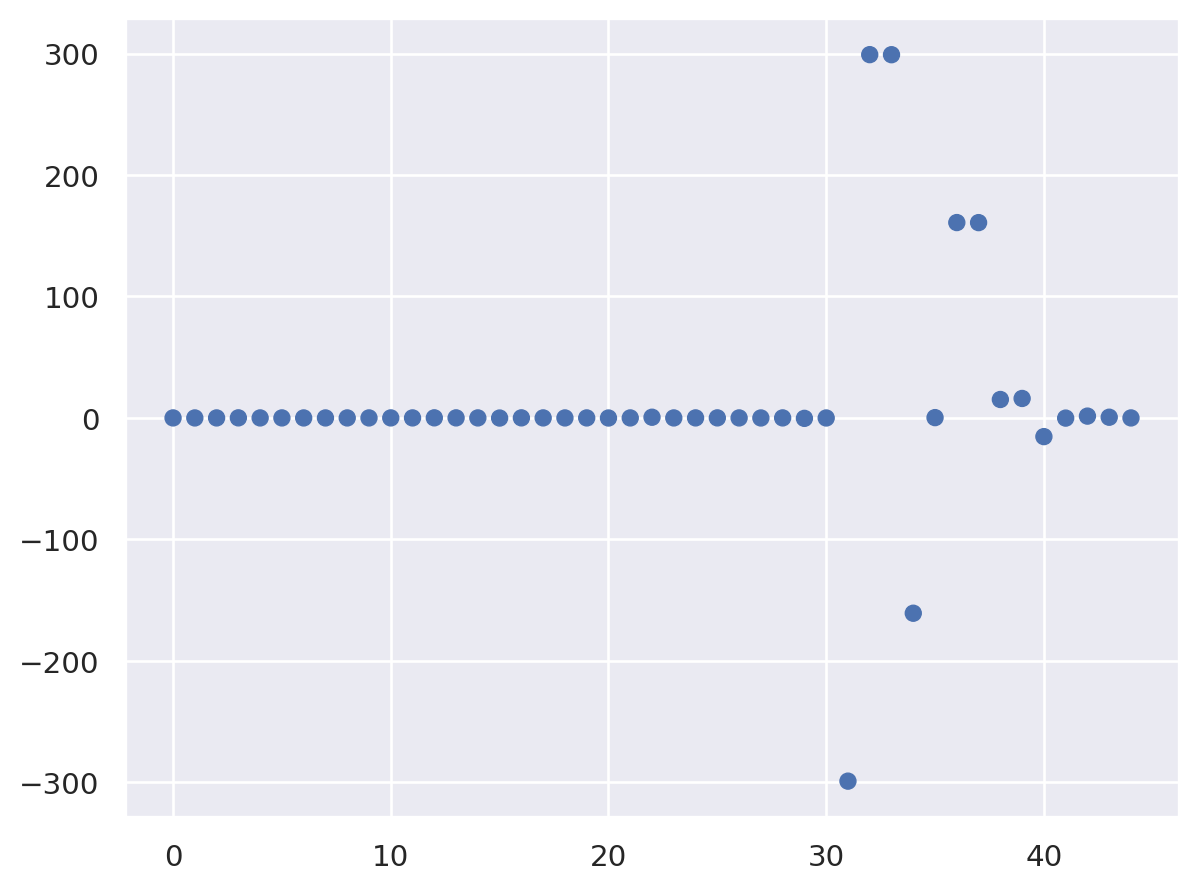

In [67]:
so.Plot(x = np.arange(len(modeloLineal.coef_)),y= modeloLineal.coef_).add(so.Dot())

Observando los coeficientes, hay algunos grandes que se cancelan, indicando una posible colinealidad, lo que sugiere utilizar una regresión Ridge.

Veamos primero si las variables están en la misma escala.

In [69]:
X.max()

GP                41.00000
Min_per           98.00000
Ortg             834.00000
usg               50.00000
eFG              150.00000
TS_per           150.00000
ORB_per         1576.60000
DRB_per         1385.00000
AST_per          100.00000
TO_per           100.00000
FTM              312.00000
FTA              374.00000
FT_per             1.00000
twoPM            333.00000
twoPA            678.00000
twoP_per           1.00000
TPM              147.00000
TPA              394.00000
TP_per             1.00000
blk_per         1072.00000
stl_per          118.20000
ftr             1000.00000
porpag             8.65819
adjoe            678.94200
pfr              720.00000
year            2021.00000
pid            74254.00000
drtg             131.46100
adrtg            144.68500
dporpag            5.80053
stops            360.57200
bpm              685.31300
obpm             161.99500
dbpm             523.31900
gbpm             269.50800
mp                50.00000
ogbpm            225.48500
d

Hay bastante diferencia en las escalas de las variables. Para poder comparar mejor los coeficientes, escalemos todas las variables al intervalo [0,1]

In [72]:
X_scaled = (X- X.min())/(X.max()-X.min())
print(X_scaled.min())
print(X_scaled.max())

GP             0.0
Min_per        0.0
Ortg           0.0
usg            0.0
eFG            0.0
TS_per         0.0
ORB_per        0.0
DRB_per        0.0
AST_per        0.0
TO_per         0.0
FTM            0.0
FTA            0.0
FT_per         0.0
twoPM          0.0
twoPA          0.0
twoP_per       0.0
TPM            0.0
TPA            0.0
TP_per         0.0
blk_per        0.0
stl_per        0.0
ftr            0.0
porpag         0.0
adjoe          0.0
pfr            0.0
year           0.0
pid            0.0
drtg           0.0
adrtg          0.0
dporpag        0.0
stops          0.0
bpm            0.0
obpm           0.0
dbpm           0.0
gbpm           0.0
mp             0.0
ogbpm          0.0
dgbpm          0.0
oreb           0.0
dreb           0.0
treb           0.0
ast            0.0
stl            0.0
blk            0.0
Unnamed: 65    0.0
dtype: float64
GP             1.0
Min_per        1.0
Ortg           1.0
usg            1.0
eFG            1.0
TS_per         1.0
ORB_per        1

Ahora que todas las variables están entre 0 y 1. Usamos el escalamiento MinMax

**Escalamiento MinMax**

Escalamos las variables utilizando escalamiento MinMax.

La regresión lineal ordinaria es invariante por escalamiento lineal.

Esto quiere decir que si bien los coeficientes van a cambiar, las predicciones se van a mantener iguales.

El escalamiento no va a solucionar los problemas de colinealidad, pero nos permite comparar mejor los coeficientes.

Dado que solo queremos comparar coeficientes, no es necesario escalar la variable respuesta _y_

In [73]:
X_scaled = (X - X.min()) / (X.max() - X.min())

In [75]:
modeloLineal = linear_model.LinearRegression()
modeloLineal.fit(X_scaled, y)

y_pred = modeloLineal.predict(X_scaled)

rmse = np.sqrt(mean_squared_error(y, y_pred))
print(f"Raíz del Error Cuadrático Medio: {rmse:.5f}")
r2 = r2_score(y, y_pred)
print(f"R cuadrado: {r2:.5f}")

Raíz del Error Cuadrático Medio: 0.53186
R cuadrado: 0.98845


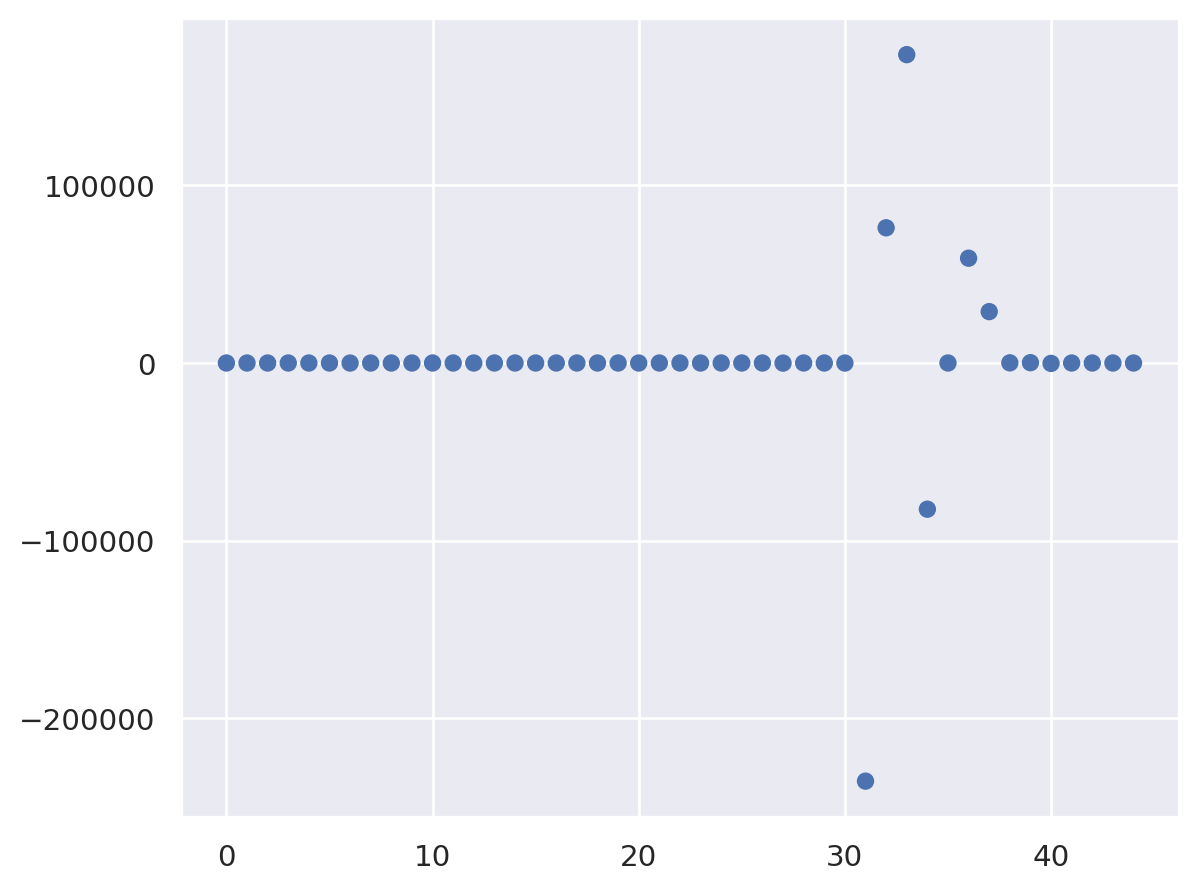

In [76]:

# Seguimos observando coeficientes enormes que se cancelan mutuamente.
so.Plot(x = np.arange(len(modeloLineal.coef_)), y = modeloLineal.coef_).add(so.Dot())

A partir de acá comienza lo del modelo de regresión Ridge. Cosa que (al momento de hacer ésto) todavía no vi.

In [77]:
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [79]:
modeloRidge = linear_model.Ridge(alpha = 1)  # Ejercicio: calcular alpha por validacion cruzada

# Entrenamiento
modeloRidge.fit(X_train, y_train)

# Predicciones
y_pred = modeloRidge.predict(X_train)

# Evaluación
rmse = np.sqrt(mean_squared_error(y_train, y_pred))
print(f"Raíz del Error Cuadrático Medio: {rmse:.5f}")
r2 = r2_score(y_train, y_pred)
print(f"R cuadrado: {r2:.5f}")

Raíz del Error Cuadrático Medio: 0.53298
R cuadrado: 0.98841


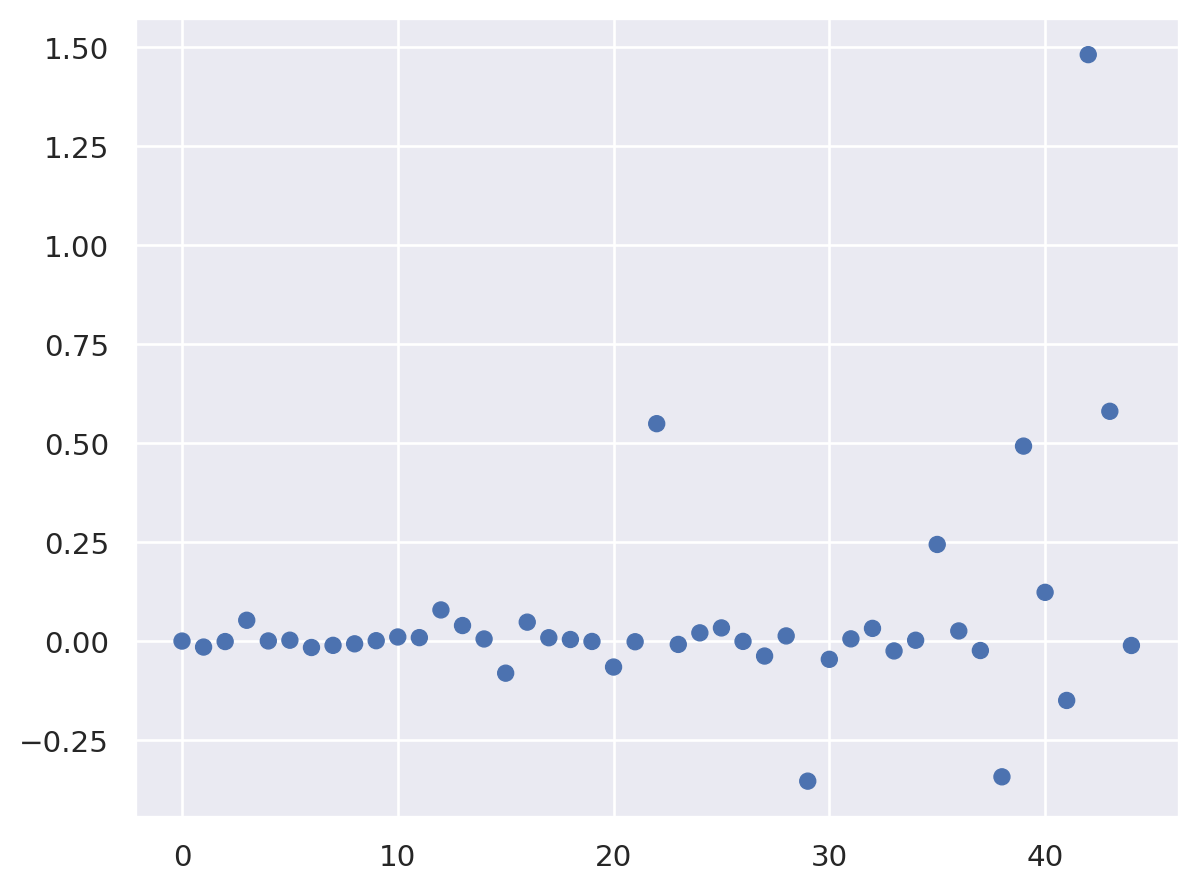

In [80]:
# Observamos los coeficientes
so.Plot(x = np.arange(len(modeloRidge.coef_)), y = modeloRidge.coef_).add(so.Dot())

Redujimos el problema de coeficientes grandes que se anulan, pero todavía resulta difícil comparar los pesos de las distintas variables.

Además en el modelo lineal Ridge penalizamos coeficientes grandes. Si las variables están a distinta escala, esto hace que penalicemos más a algunas variables que a otras.

En Regresión Ridge casi siempre es necesario escalar las variables.

Reescalamos todas las variables a [0,1].

Utilizamos ahora MinMaxScaler de sklearn para las transformaciones. Esto permite calcular los parámetros de la transformación en el conjunto de entrenamiento y aplicarlo en el conjunto de testeo.

In [81]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler().set_output(transform="pandas") # La última opción hace que nos devuelva un DataFrame

In [82]:

# fit_transform calcula los coeficientes de la transformación y la aplica.
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled.max()

GP             1.0
Min_per        1.0
Ortg           1.0
usg            1.0
eFG            1.0
TS_per         1.0
ORB_per        1.0
DRB_per        1.0
AST_per        1.0
TO_per         1.0
FTM            1.0
FTA            1.0
FT_per         1.0
twoPM          1.0
twoPA          1.0
twoP_per       1.0
TPM            1.0
TPA            1.0
TP_per         1.0
blk_per        1.0
stl_per        1.0
ftr            1.0
porpag         1.0
adjoe          1.0
pfr            1.0
year           1.0
pid            1.0
drtg           1.0
adrtg          1.0
dporpag        1.0
stops          1.0
bpm            1.0
obpm           1.0
dbpm           1.0
gbpm           1.0
mp             1.0
ogbpm          1.0
dgbpm          1.0
oreb           1.0
dreb           1.0
treb           1.0
ast            1.0
stl            1.0
blk            1.0
Unnamed: 65    1.0
dtype: float64

In [83]:
# Inicializamos el modelo lineal
modeloLineal = linear_model.Ridge(alpha = 1) 

# Entrenamiento
modeloLineal.fit(X_train_scaled, y_train)

# Predicciones
y_pred = modeloLineal.predict(X_train_scaled)

# Evaluación
rmse = np.sqrt(mean_squared_error(y_train, y_pred))
print(f"Raíz del Error Cuadrático Medio: {rmse:.5f}")
r2 = r2_score(y_train, y_pred)
print(f"R cuadrado: {r2:.5f}")

Raíz del Error Cuadrático Medio: 0.54374
R cuadrado: 0.98794


In [84]:

# Estará bien hacerlo así?
X_test_scaled = scaler.fit_transform(X_test)

In [85]:

# Predicciones
y_pred = modeloLineal.predict(X_test_scaled)

# Evaluación
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Raíz del Error Cuadrático Medio: {rmse:.5f}")
r2 = r2_score(y_test, y_pred)
print(f"R cuadrado: {r2:.5f}")

Raíz del Error Cuadrático Medio: 1.70927
R cuadrado: 0.87993


No funciona bien porque aplicamos una transformación distinta, los valores de x_min y x_max se recalcularon.

La forma correcta es usar solo transform, sin "fitear" nuevamente los parametros del ajuste.

In [86]:
# Tenemos que fittear en entrenamiento y aplicar esa transformación a los datos de testeo
scaler.fit(X_train)   # Primero fiteamos (este paso no es necesario si ya hicimos fit_transform en X_train)
X_test_scaled = scaler.transform(X_test)  # Luego transformamos

In [87]:

# Predicciones
y_pred = modeloLineal.predict(X_test_scaled)

# Evaluación
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Raíz del Error Cuadrático Medio: {rmse:.5f}")
r2 = r2_score(y_test, y_pred)
print(f"R cuadrado: {r2:.5f}")

Raíz del Error Cuadrático Medio: 0.53805
R cuadrado: 0.98810


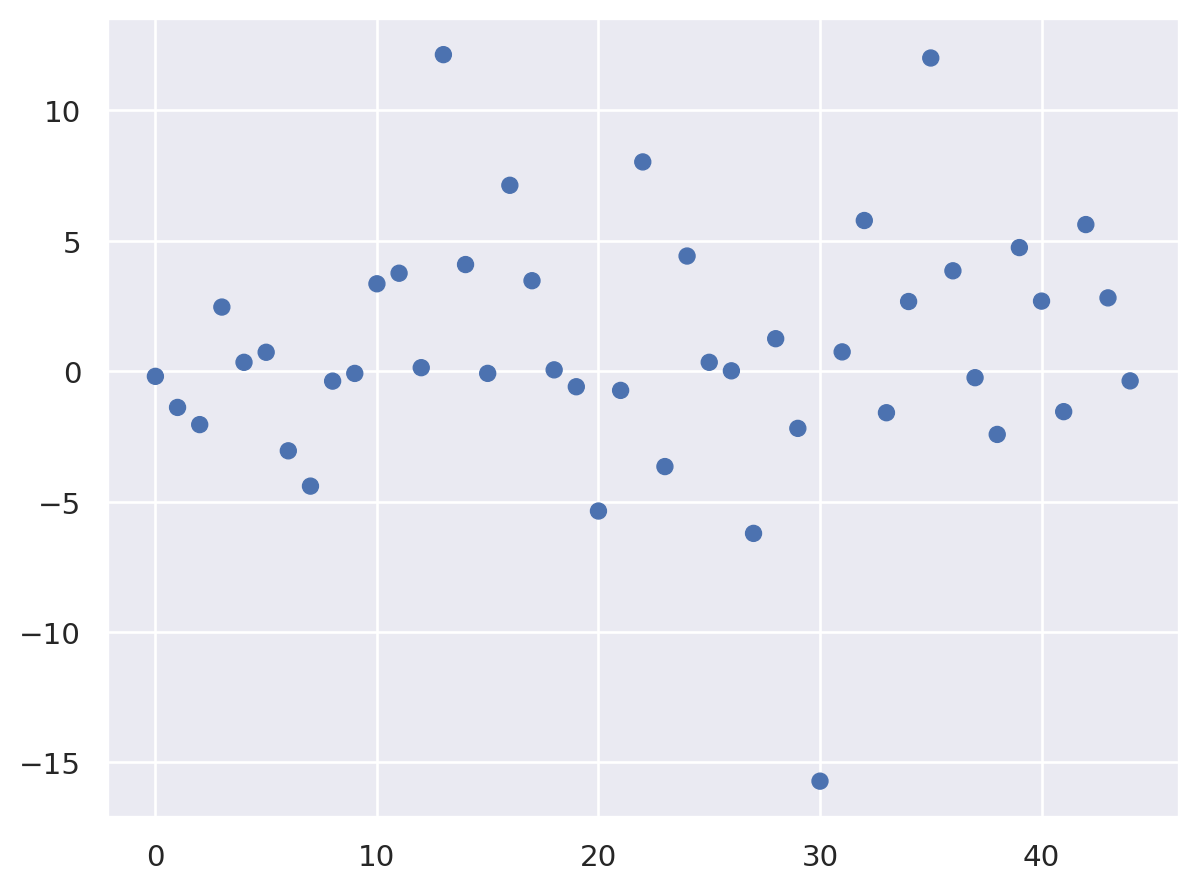

In [88]:
# Graficamos los coeficientes
so.Plot(x = np.arange(len(modeloLineal.coef_)), y = modeloLineal.coef_).add(so.Dot())


Vemos que ahora los coeficientes tienen rangos similares.

No entendí nada jeje
